# Renger 2026 Figure 2(c-f) Qualitative Reproduction

**Audience**
- Julia users already comfortable with `QuantumCircuit.jl` who want a compact exact-circuit reproduction of the local physics behind Fig. 2(c)-(f) of the Renger 2026 paper.

**Prerequisites**
- Basic Julia syntax.
- Familiarity with `CompositeSystem`, `build_model`, `spectrum`, and `evolve`.
- A working local checkout of this repository.

**What You Will Learn**
- How to build two reduced exact-circuit local branches from the baseline Renger snapshot: `QB1-TC1-CR` for MOVE and `QB2-TC2-CR` for CZ.
- How to track dressed avoided crossings against locally defined diabatic states.
- How to generate paper-aligned fixed-window qubit excited-state maps for Fig. 2(e) and Fig. 2(f) on derived frequency axes.
- How to separate a resonance map from a fully calibrated logical gate.

**Runtime Profile**
- Reduced exact-circuit defaults: `charge_cutoff = 3`, `TC ncut = 4`, and compact exploratory flux windows for the spectroscopy and fixed-window map panels.
- Optional truncation checks are present but disabled by default.

**Important Caveat**
- The baseline source of truth is `paper_local_priors.toml`, with the central resonator fixed at the Table II paper-exact `4.22 GHz`.
- If `output/renger2026/fig2_ef_retune_working.toml` exists, this notebook overlays those working TC/gate-time values on top of the baseline snapshot.
- Appendix D measures the CZ calibration landscape through a higher-level pulse-and-readout sequence; here we use the local branch qubit excited-state probability as the clean reduced-model proxy.


## Outline

1. Activate the local environment and import the exact-circuit tools used in this notebook.
2. Load the frozen Renger priors and summarize the local `QB1`, `TC1`, and `CR` parameters.
3. Build notebook-local helpers for a reduced exact-circuit `QB-TC-CR` model.
4. Reproduce a MOVE-like avoided crossing between states approximating `|eg0⟩` and `|gg1⟩`.
5. Reproduce a CZ-like avoided crossing between states approximating `|eg1⟩` and `|fg0⟩`.
6. Generate a fixed-window MOVE population scan analogous to Fig. 2(e).
7. Generate a fixed-window CZ resonance scan analogous to Fig. 2(f).
8. Check one flux-quench sanity case with `FluxControl` and show why this notebook stops at resonance physics rather than claiming a finished logical gate calibration.


In [2]:
using Pkg

function find_repo_root(start::AbstractString)
    candidates = [
        normpath(start),
        normpath(joinpath(start, "..")),
        normpath(joinpath(start, "..", "..")),
    ]

    for candidate in unique(candidates)
        project_toml = joinpath(candidate, "Project.toml")
        if isfile(project_toml)
            content = read(project_toml, String)
            occursin("QuantumCircuit", content) && return candidate
        end
    end

    error("Could not find the QuantumCircuit.jl repository root from $(start).")
end

repo_root = find_repo_root(pwd())
Pkg.activate(repo_root)
Pkg.instantiate()

using Printf
using TOML
using CairoMakie
using QuantumCircuit
using QuantumToolbox: basis, dag, eigenstates, kron, Ket, QuantumObject

include(joinpath(repo_root, "output", "jupyter-notebook", "makie_helpers.jl"))
activate_notebook_theme!()

const FIG2_CHARGE_CUTOFF = 3
const FIG2_MOVE_PLOT_TC_FLUX = 0.34
const FIG2_CZ_PLOT_TC_FLUX = 0.34
const FIG2_MOVE_T_GATE_DEFAULT = 100.0
const FIG2_CZ_T_GATE_DEFAULT = 120.0
const RUN_TRUNCATION_CHECKS = false
figure_exports = Dict{Symbol, NamedTuple}()

nothing


  Activating project at `~/Research/20_Projects/QuantumCircuit.jl`


## Step 1 - Build a local exact-circuit model and local-eigenstate labels

The key modeling detail is that the exact-circuit basis used internally by `QuantumCircuit.jl` is a charge basis, not a dressed transmon basis. For Fig. 2(c)-(f), we therefore define the diabatic labels `|g⟩`, `|e⟩`, and `|f⟩` from the **isolated local exact-circuit eigenstates** of the qubit and coupler, then tensor those with resonator Fock states.

This keeps the avoided-crossing labels physically meaningful while the coupled `QB-TC-CR` model still uses the full circuit Hamiltonian.


In [3]:
overlay_candidate = joinpath(repo_root, "output", "renger2026", "fig2_ef_retune_working.toml")
const FIG2_OVERLAY_PATH = isfile(overlay_candidate) ? overlay_candidate : nothing
snapshot = load_renger2026_snapshot(; overlay_path = FIG2_OVERLAY_PATH)
include(joinpath(repo_root, "output", "jupyter-notebook", "renger2026_fig2_branch_helpers.jl"))

gate_times = fig2_gate_times(snapshot; move_default = FIG2_MOVE_T_GATE_DEFAULT, cz_default = FIG2_CZ_T_GATE_DEFAULT)
move_system = local_exact_system(snapshot; branch = :move)
cz_system = local_exact_system(snapshot; branch = :cz)

nothing


## Step 2 - Frozen local parameter snapshot

This notebook uses the existing baseline Renger snapshot plus an optional working overlay for Fig. 2(e)(f) retuning.

`QB1` and `QB2` are treated as locally identified, while `TC1` and `TC2` remain weakly identified local seeds unless the working overlay overrides them. That is why the notebook is careful to claim only **qualitative** agreement with the paper panels.


In [4]:
parameter_summary, coupling_summary = parameter_rows(
    snapshot;
    move_t_gate_ns = gate_times.move,
    cz_t_gate_ns = gate_times.cz,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)
branch_summary = (
    move_branch = branch_spec(:move).label,
    cz_branch = branch_spec(:cz).label,
    overlay_path = FIG2_OVERLAY_PATH,
)

(; branch_summary, parameter_summary, coupling_summary)


(branch_summary = (move_branch = "QB1-TC1-CR", cz_branch = "QB2-TC2-CR"), parameter_summary = NamedTuple{(:device, :fit, :f01_ghz, :EC_ghz, :EJmax_ghz, :flux, :asymmetry)}[(device = "QB1", fit = "identified", f01_ghz = 4.6707, EC_ghz = 0.1995, EJmax_ghz = 14.92, flux = 0.0, asymmetry = 0.1), (device = "TC1", fit = "weakly identified", f01_ghz = 5.2566, EC_ghz = 0.105, EJmax_ghz = 34.25, flux = 0.0, asymmetry = 0.1), (device = "QB2", fit = "identified", f01_ghz = 4.4698, EC_ghz = 0.2006, EJmax_ghz = 13.65, flux = 0.0, asymmetry = 0.1), (device = "TC2", fit = "weakly identified", f01_ghz = 5.2566, EC_ghz = 0.105, EJmax_ghz = 34.25, flux = 0.0, asymmetry = 0.1), (device = "CR", fit = "paper target", f01_ghz = 4.2, EC_ghz = missing, EJmax_ghz = missing, flux = missing, asymmetry = missing)], coupling_summary = (beta_qc_qb1 = 0.017, beta_qc_qb2 = 0.022, beta_cr = 0.0225, cr_f01_ghz = 4.2, move_t_gate_ns = 100.0, cz_t_gate_ns = 120.0, charge_cutoff = 3))

## Step 3 - Fig. 2(c) analog: MOVE avoided crossing

The MOVE avoided crossing is built on the `QB1-TC1-CR` branch. We plot only the ordered dressed branches and keep nearby dressed modes in the background to make the local repulsion visible.


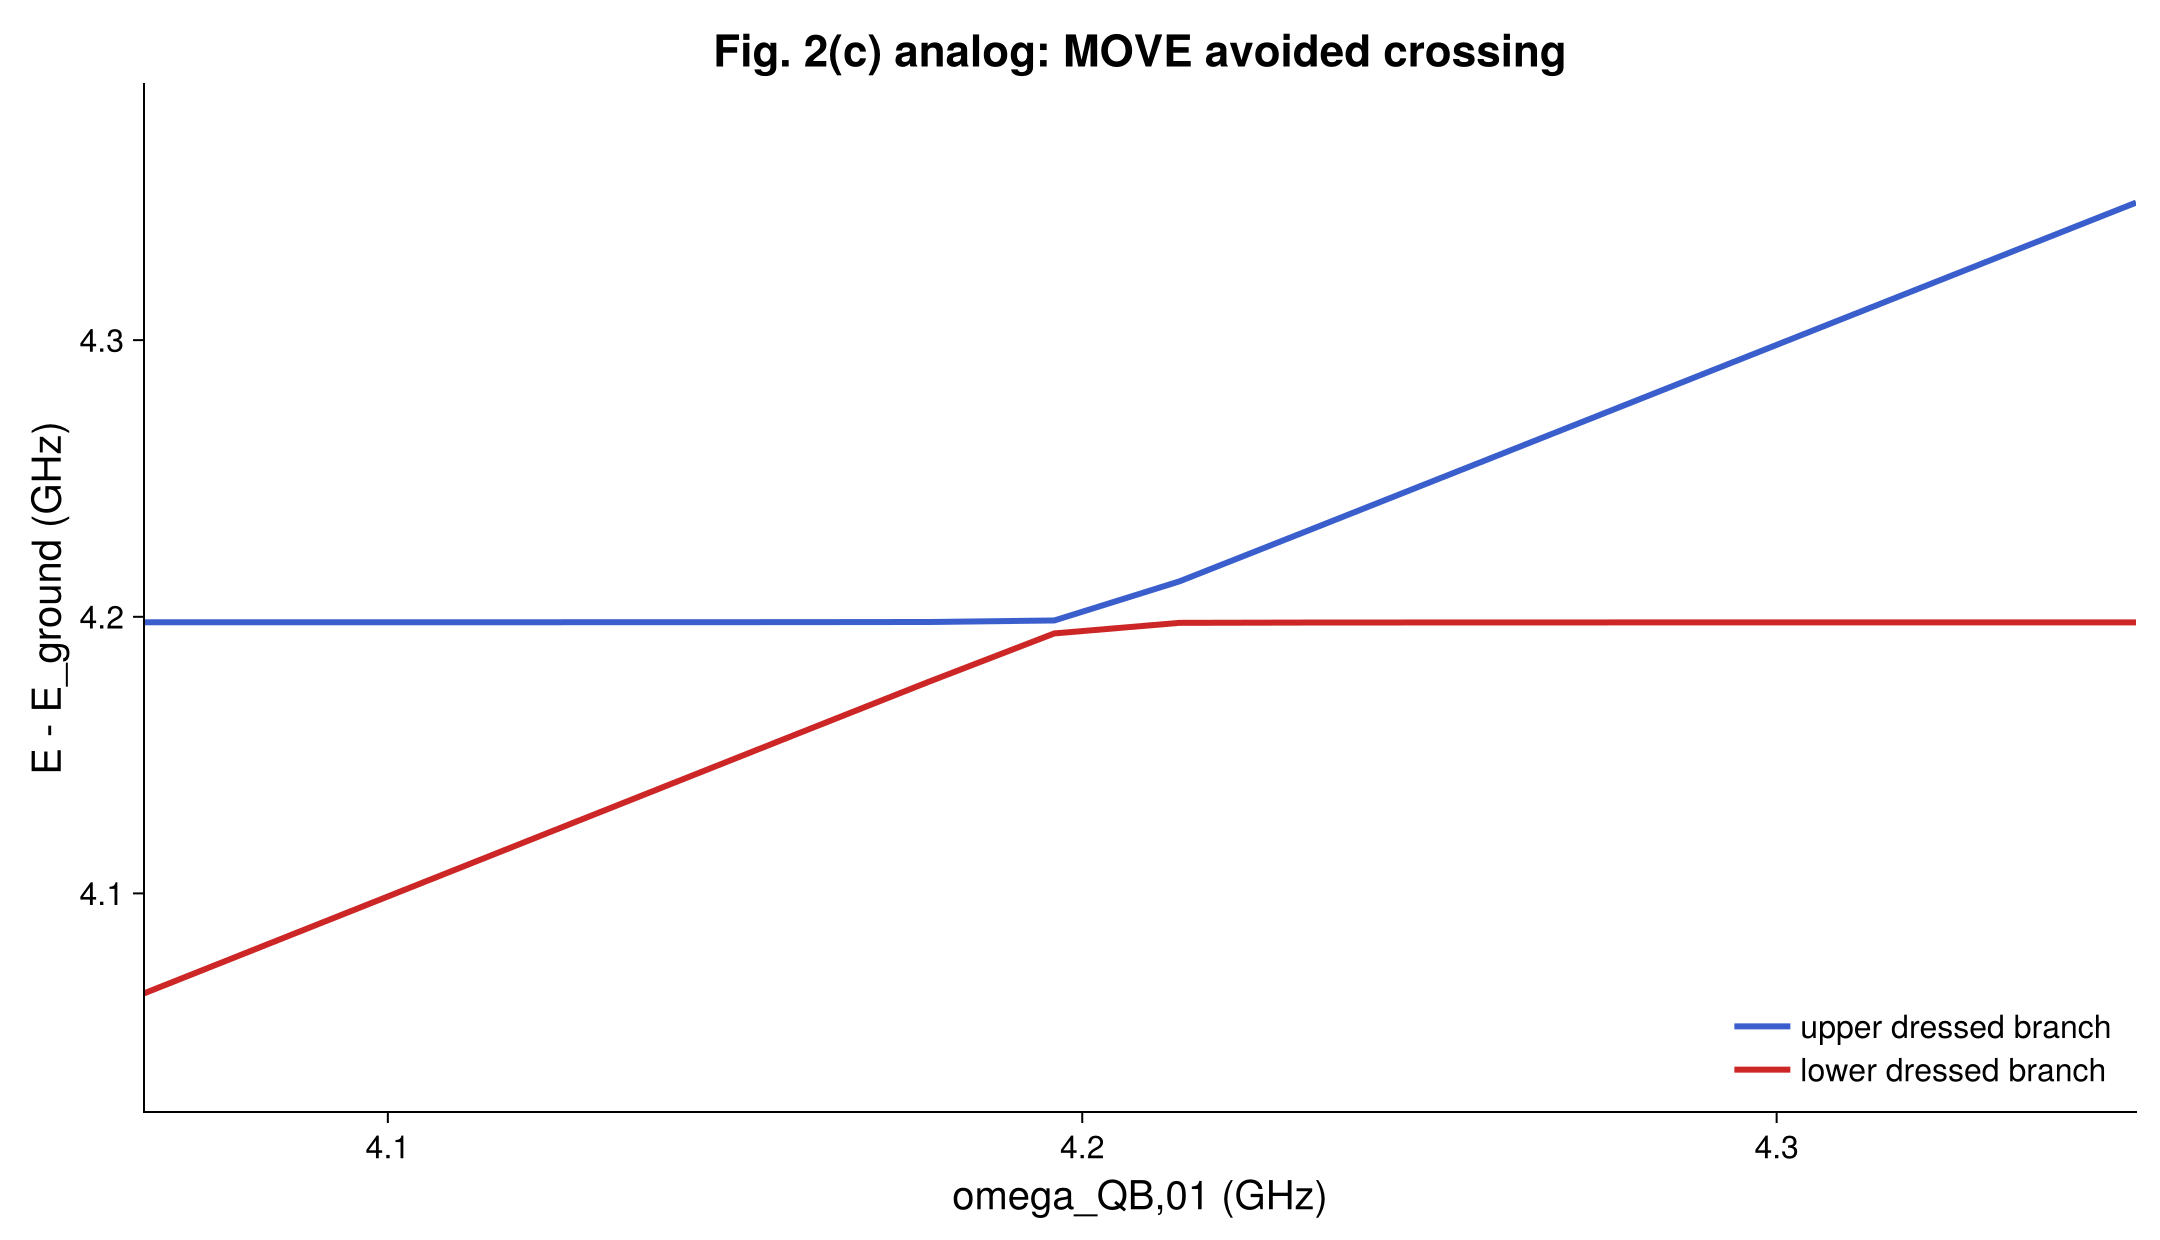

(saved = (svg = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2c_move_avoided_crossing.svg", png = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2c_move_avoided_crossing.png"), plotted_tc_flux = 0.34, highlighted_pair = (2, 3), move_reference = (q_flux = 0.235, q_ghz = 4.1778, tc_flux = 0.34, tc_ghz = 4.6326, pair_abs = (2, 3), gap_ghz = 0.0217, a_pair_support = 0.9973, b_pair_support = 0.9956, score = 2.1905), move_reference_third_mode = (rel_index = 3.0, abs_index = 4.0, support = 0.007, comparable = 0.0), move_gap = (q_flux = 0.2325, q_ghz = 4.196, tc_flux = 0.34, tc_ghz = 4.6326, pair_abs = (2, 3), gap_ghz = 0.0047, lower_a_overlap = 0.8539, lower_b_overlap = 0.1405, upper_a_overlap = 0.1432, upper_b_overlap = 0.8551, a_pair_support = 0.9971, b_pair_support = 0.9956, lower_branch_support = 0.9944, upper_branch_support = 0.9983, support_score = 2.1775, third_mode_abs_index = 4.0, third_mode_support

In [5]:
move_plot_tc_flux = FIG2_MOVE_PLOT_TC_FLUX
move_q_fluxes = collect(range(0.21, 0.25; length = 17))
move_rows = adiabatic_fan_rows(
    move_system,
    snapshot,
    move_q_fluxes,
    move_plot_tc_flux;
    branch_pair_a = (1, 0, 0),
    branch_pair_b = (0, 0, 1),
    which = :move,
    branch = :move,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)
move_pair = choose_highlighted_pair(move_rows)

move_x = [row.q_ghz for row in move_rows]
move_lower, move_upper = highlighted_pair_curves(move_rows, move_pair)
move_pair_span = maximum(move_upper) - minimum(move_lower)
move_y_pad = max(0.02, 0.15 * move_pair_span)
move_ylims = (minimum(move_lower) - move_y_pad, maximum(move_upper) + move_y_pad)
move_fan_curves = adiabatic_fan_curves(move_rows; ylims = move_ylims)
move_background_y = fan_y_values(move_fan_curves)
move_y_values = isempty(move_background_y) ? vcat(move_lower, move_upper) : vcat(move_lower, move_upper, move_background_y)
move_xlims = (minimum(move_x), maximum(move_x))
move_ylims = (minimum(move_y_values) - move_y_pad, maximum(move_y_values) + move_y_pad)

move_fig = line_figure(
    vcat(
        move_fan_curves,
        [
            (x = move_x, y = move_upper, label = "upper dressed branch", color = FIG2_COLORS.dressed_a),
            (x = move_x, y = move_lower, label = "lower dressed branch", color = FIG2_COLORS.dressed_b),
        ],
    );
    title = "Fig. 2(c) analog: MOVE avoided crossing",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "E - E_ground (GHz)",
    size = NOTEBOOK_WIDE,
    legend_position = :rb,
    xlims = move_xlims,
    ylims = move_ylims,
)
move_saved = save_figure(move_fig, repo_root, "figure2c_move_avoided_crossing")
figure_exports[:figure2c] = move_saved

display(move_fig)

move_gap = adiabatic_gap_summary(move_rows, move_pair)
move_validation = adiabatic_validation_summary(move_rows, move_pair, move_gap)
move_reference_third_mode = third_mode_support_summary(move_rows[move_pair.row_index], move_pair)

(
    saved = move_saved,
    plotted_tc_flux = round4(move_plot_tc_flux),
    highlighted_pair = move_pair.pair_abs,
    move_reference = compact_namedtuple((
        q_flux = move_pair.q_flux,
        q_ghz = move_pair.q_ghz,
        tc_flux = move_pair.tc_flux,
        tc_ghz = move_pair.tc_ghz,
        pair_abs = move_pair.pair_abs,
        gap_ghz = move_pair.gap_ghz,
        a_pair_support = move_pair.a_pair_support,
        b_pair_support = move_pair.b_pair_support,
        score = move_pair.score,
    )),
    move_reference_third_mode = compact_namedtuple(move_reference_third_mode),
    move_gap = compact_namedtuple(move_gap),
    move_validation = move_validation,
)


## Step 4 - Fig. 2(d) analog: CZ resonance avoided crossing

The CZ-side avoided crossing is built on the `QB2-TC2-CR` branch. As in the paper, the horizontal axis is the qubit frequency during the gate, `omega_QB,01`, while the tracked dressed branches come from the `|eg1⟩` and `|fg0⟩` manifold.


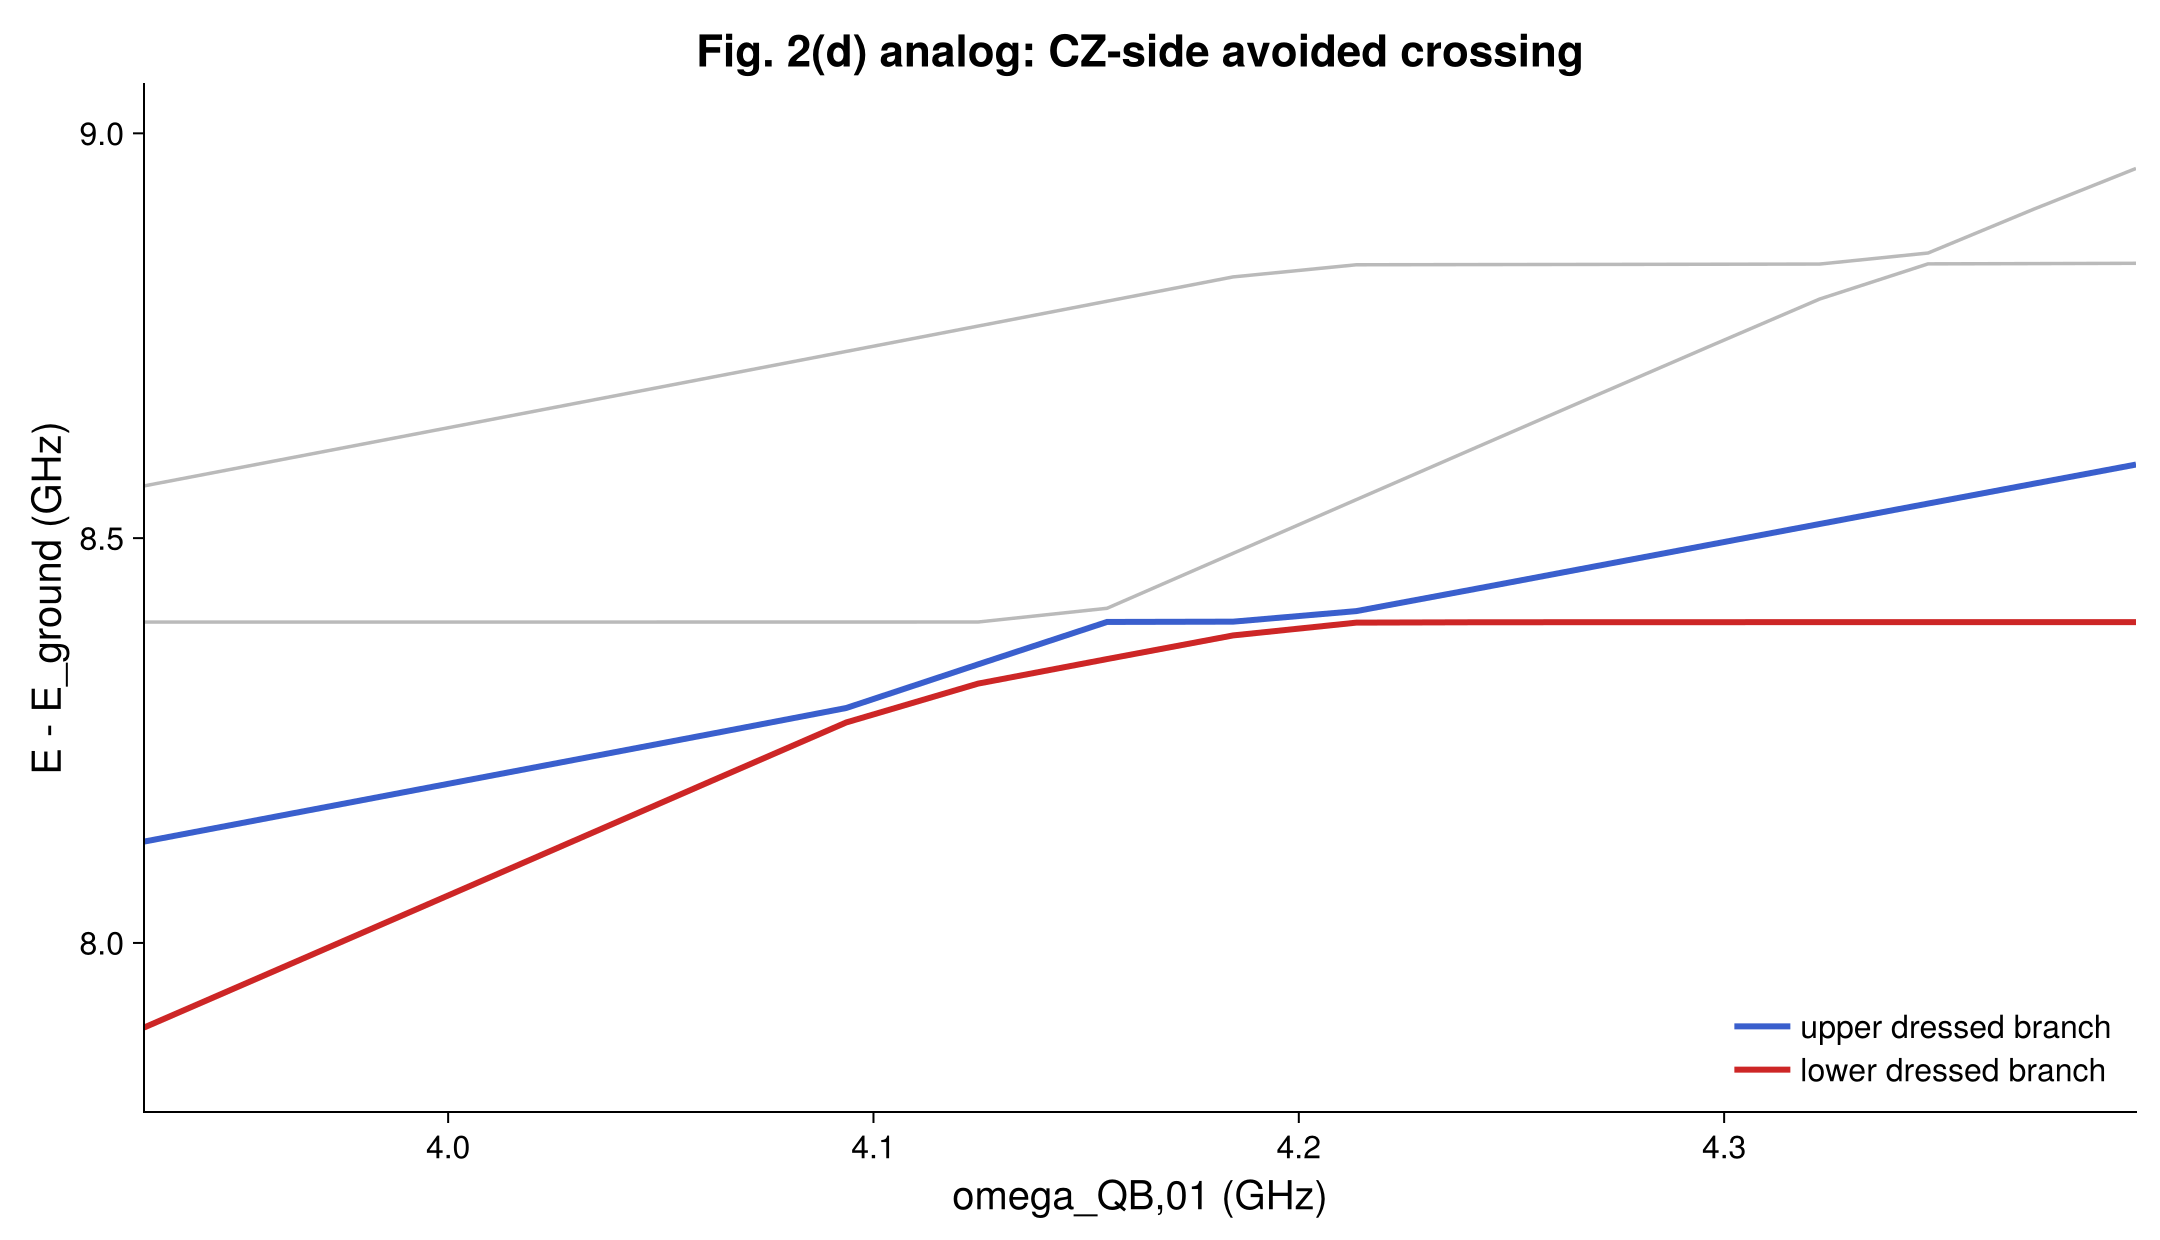

(saved = (svg = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2d_cz_avoided_crossing.svg", png = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2d_cz_avoided_crossing.png"), plotted_tc_flux = 0.34, highlighted_pair = (5, 6), cz_reference = (q_flux = 0.22, q_ghz = 4.0619, tc_flux = 0.34, tc_ghz = 4.6326, pair_abs = (5, 6), gap_ghz = 0.0582, a_pair_support = 0.9925, b_pair_support = 0.9938, score = 2.1818), cz_reference_third_mode = (rel_index = 7.0, abs_index = 8.0, support = 0.0104, comparable = 0.0), cz_gap = (q_flux = 0.195, q_ghz = 4.2135, tc_flux = 0.34, tc_ghz = 4.6326, pair_abs = (5, 6), gap_ghz = 0.0142, lower_a_overlap = 0.0456, lower_b_overlap = 0.0, upper_a_overlap = 0.9443, upper_b_overlap = 0.0004, a_pair_support = 0.9899, b_pair_support = 0.0004, lower_branch_support = 0.0457, upper_branch_support = 0.9447, support_score = 1.0369, third_mode_abs_index = 7.0, third_mode_support = 0.9834, th

In [6]:
cz_plot_tc_flux = FIG2_CZ_PLOT_TC_FLUX
cz_q_fluxes = collect(range(0.16, 0.24; length = 17))
cz_rows = adiabatic_fan_rows(
    cz_system,
    snapshot,
    cz_q_fluxes,
    cz_plot_tc_flux;
    branch_pair_a = (1, 0, 1),
    branch_pair_b = (2, 0, 0),
    which = :cz,
    branch = :cz,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)
cz_pair = choose_highlighted_pair(cz_rows)

cz_x = [row.q_ghz for row in cz_rows]
cz_lower, cz_upper = highlighted_pair_curves(cz_rows, cz_pair)
cz_pair_span = maximum(cz_upper) - minimum(cz_lower)
cz_y_pad = max(0.02, 0.15 * cz_pair_span)
cz_ylims = (minimum(cz_lower) - cz_y_pad, maximum(cz_upper) + cz_y_pad)
cz_fan_curves = adiabatic_fan_curves(cz_rows; ylims = cz_ylims)
cz_background_y = fan_y_values(cz_fan_curves)
cz_y_values = isempty(cz_background_y) ? vcat(cz_lower, cz_upper) : vcat(cz_lower, cz_upper, cz_background_y)
cz_xlims = (minimum(cz_x), maximum(cz_x))
cz_ylims = (minimum(cz_y_values) - cz_y_pad, maximum(cz_y_values) + cz_y_pad)

cz_fig = line_figure(
    vcat(
        cz_fan_curves,
        [
            (x = cz_x, y = cz_upper, label = "upper dressed branch", color = FIG2_COLORS.dressed_a),
            (x = cz_x, y = cz_lower, label = "lower dressed branch", color = FIG2_COLORS.dressed_b),
        ],
    );
    title = "Fig. 2(d) analog: CZ-side avoided crossing",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "E - E_ground (GHz)",
    size = NOTEBOOK_WIDE,
    legend_position = :rb,
    xlims = cz_xlims,
    ylims = cz_ylims,
)
cz_saved = save_figure(cz_fig, repo_root, "figure2d_cz_avoided_crossing")
figure_exports[:figure2d] = cz_saved

display(cz_fig)

cz_gap = adiabatic_gap_summary(cz_rows, cz_pair)
cz_validation = adiabatic_validation_summary(cz_rows, cz_pair, cz_gap)
cz_reference_third_mode = third_mode_support_summary(cz_rows[cz_pair.row_index], cz_pair)

(
    saved = cz_saved,
    plotted_tc_flux = round4(cz_plot_tc_flux),
    highlighted_pair = cz_pair.pair_abs,
    cz_reference = compact_namedtuple((
        q_flux = cz_pair.q_flux,
        q_ghz = cz_pair.q_ghz,
        tc_flux = cz_pair.tc_flux,
        tc_ghz = cz_pair.tc_ghz,
        pair_abs = cz_pair.pair_abs,
        gap_ghz = cz_pair.gap_ghz,
        a_pair_support = cz_pair.a_pair_support,
        b_pair_support = cz_pair.b_pair_support,
        score = cz_pair.score,
    )),
    cz_reference_third_mode = compact_namedtuple(cz_reference_third_mode),
    cz_gap = compact_namedtuple(cz_gap),
    cz_validation = cz_validation,
)


## Step 5 - Fig. 2(e) analog: fixed-window MOVE excited-state map

For the MOVE panel we initialize the local diabatic state `|eg0⟩` on the `QB1-TC1-CR` branch, hold the system at a static operating point for a fixed interaction window, and record the **final excited-state probability of the MOVE qubit**.

This is closer to the paper calibration workflow than the previous `|gg1⟩` target-state map and makes the panel interpretable as a local readout proxy rather than as a completed logical MOVE gate.


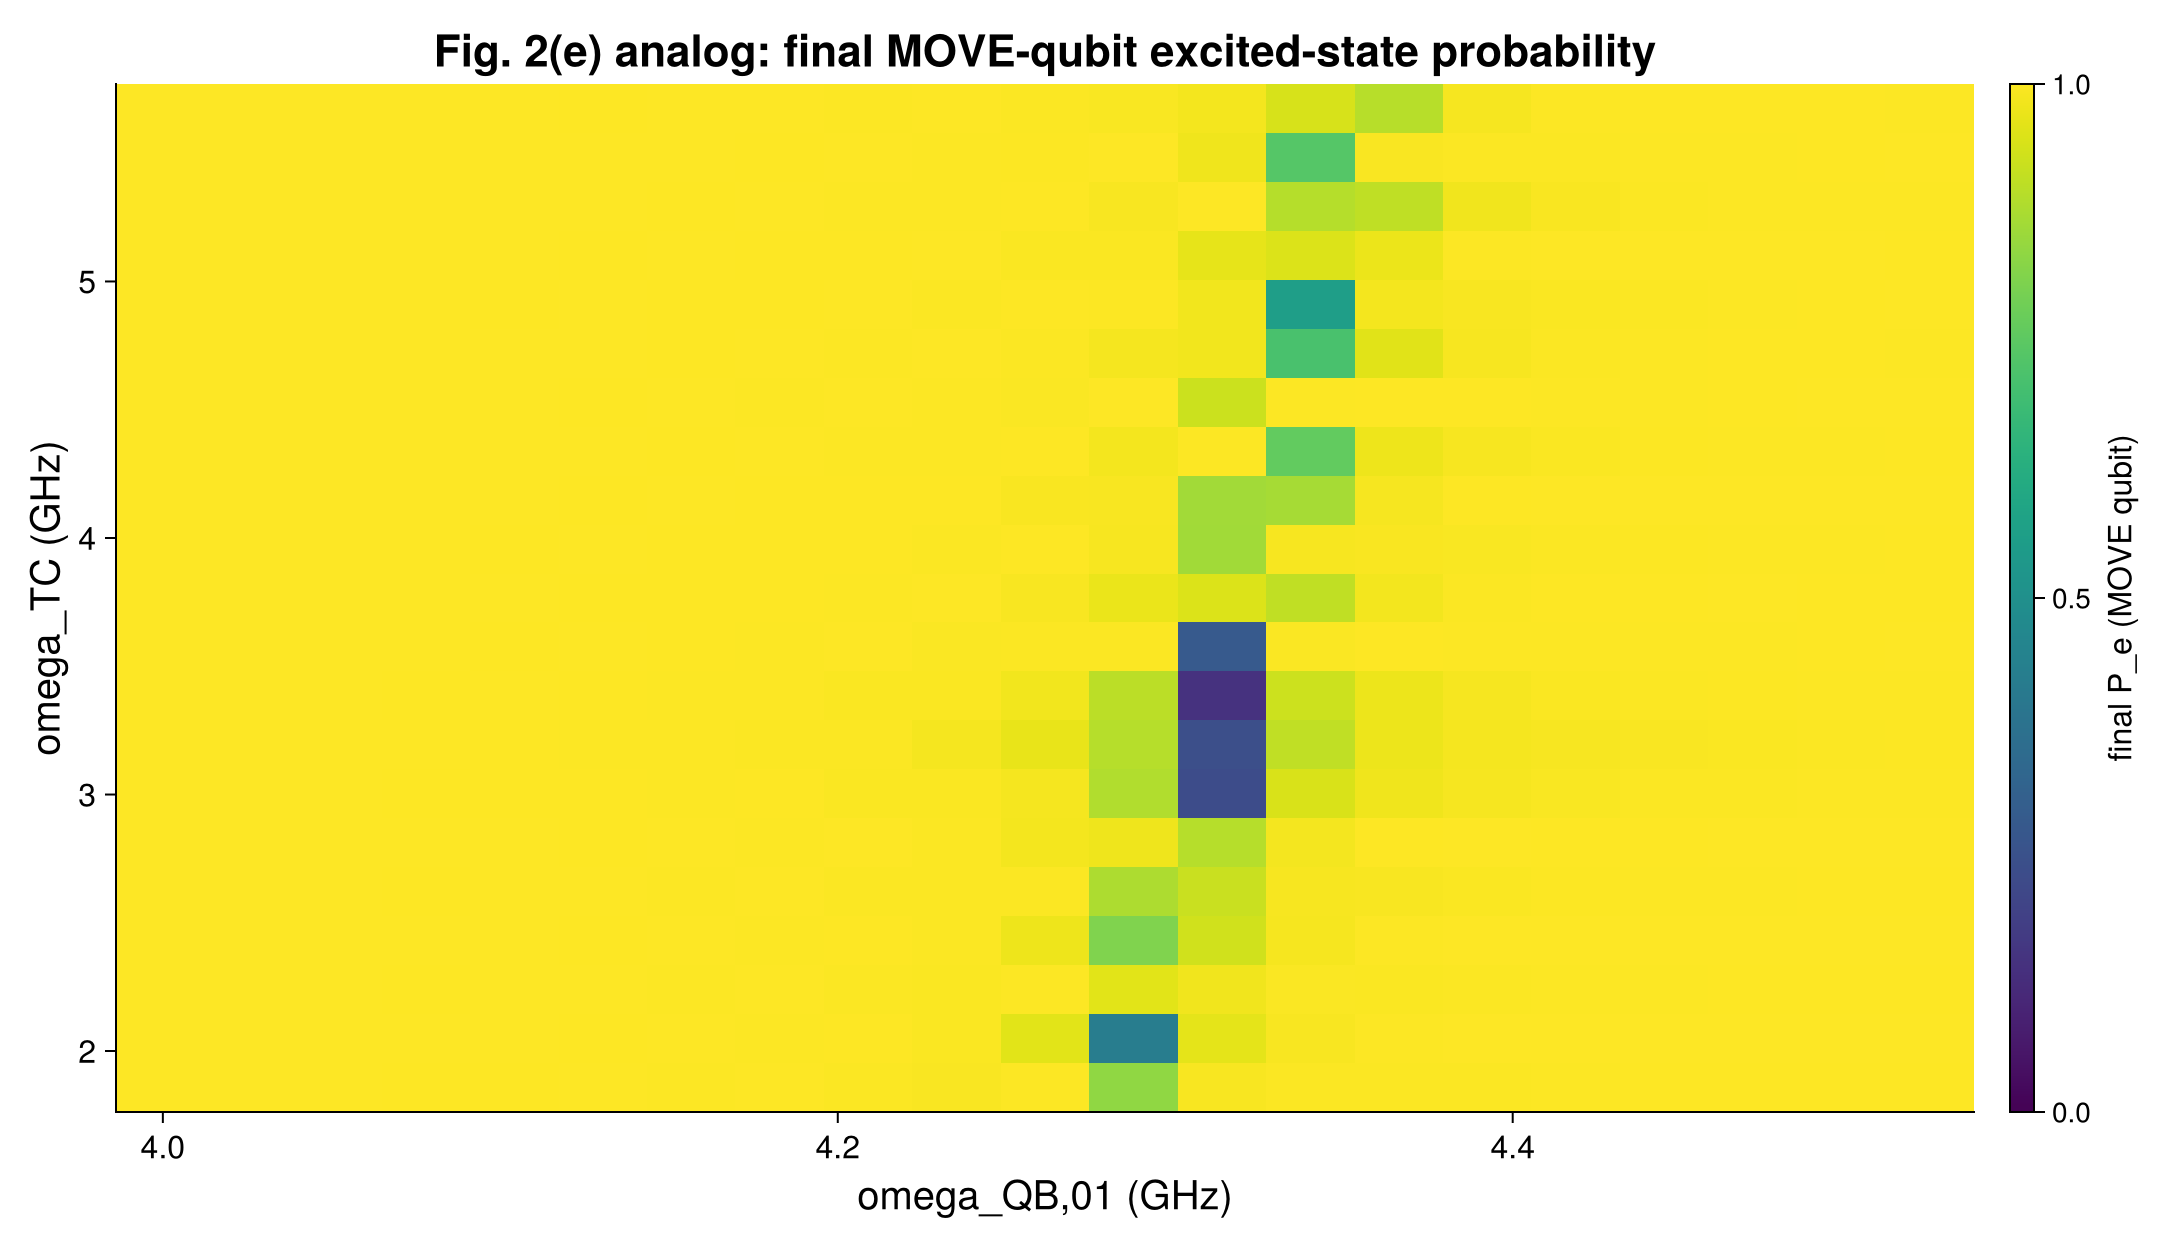

(saved = (svg = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2e_move_population_map.svg", png = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2e_move_population_map.png"), move_t_gate = 100.0, best_move_point = (q_flux = 0.228, tc_flux = 0.36, q_ghz = 4.2283, tc_ghz = 4.2256, value = 0.1433, q_edge = :interior, tc_edge = :interior), scan_rounds = 2, scan_flux_window = (q = (0.18, 0.26), tc = (0.27999999999999997, 0.48)), display_window = (xlims = (3.9861165358026227, 4.5366955089045575), ylims = (1.762285519479125, 5.769747234269154)))

In [7]:
move_scan_axes = branch_flux_axes(:move; q_points = 21, tc_points = 21)
move_scan_q_fluxes = move_scan_axes.q_fluxes
move_scan_tc_fluxes = move_scan_axes.tc_fluxes
move_t_gate = gate_times.move

move_scan = adaptive_qubit_excited_scan(
    move_system,
    snapshot,
    move_scan_q_fluxes,
    move_scan_tc_fluxes,
    (1, 0, 0),
    move_t_gate;
    branch = :move,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)

x_move = move_scan.x_values
y_move = move_scan.y_values
matrix_move = move_scan.matrix
x_move_sorted, y_move_sorted, matrix_move_sorted = ordered_heatmap_axes(x_move, y_move, matrix_move)
best_move_point = move_scan.best_point
move_display = (
    xlims = (minimum(x_move_sorted), maximum(x_move_sorted)),
    ylims = (minimum(y_move_sorted), maximum(y_move_sorted)),
)

move_heatmap_fig = heatmap_figure(
    x_move_sorted,
    y_move_sorted,
    matrix_move_sorted;
    title = "Fig. 2(e) analog: final MOVE-qubit excited-state probability",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "omega_TC (GHz)",
    colorlabel = "final P_e (MOVE qubit)",
    colorrange = (0.0, 1.0),
    xlims = move_display.xlims,
    ylims = move_display.ylims,
)
move_heatmap_saved = save_figure(move_heatmap_fig, repo_root, "figure2e_move_population_map")
figure_exports[:figure2e] = move_heatmap_saved

display(move_heatmap_fig)

(
    saved = move_heatmap_saved,
    move_t_gate = move_t_gate,
    best_move_point = compact_namedtuple(best_move_point),
    scan_rounds = move_scan.rounds,
    scan_flux_window = (q = (first(move_scan.q_fluxes), last(move_scan.q_fluxes)), tc = (first(move_scan.tc_fluxes), last(move_scan.tc_fluxes))),
    display_window = move_display,
)


## Step 6 - Fig. 2(f) analog: fixed-window CZ excited-state map

For the CZ panel we initialize `|eg1⟩` on the `QB2-TC2-CR` branch, hold at a static operating point, and record the **final excited-state probability of the CZ-branch qubit**.

Appendix D extracts the experimental CZ operating point through a higher-level sequence whose readout is routed through the MOVE qubit. This reduced notebook cannot represent that full sequence, so it uses the final excited-state probability of the isolated `QB2-TC2-CR` branch as the local proxy for the `|eg1⟩ ↔ |fg0⟩` exchange landscape.


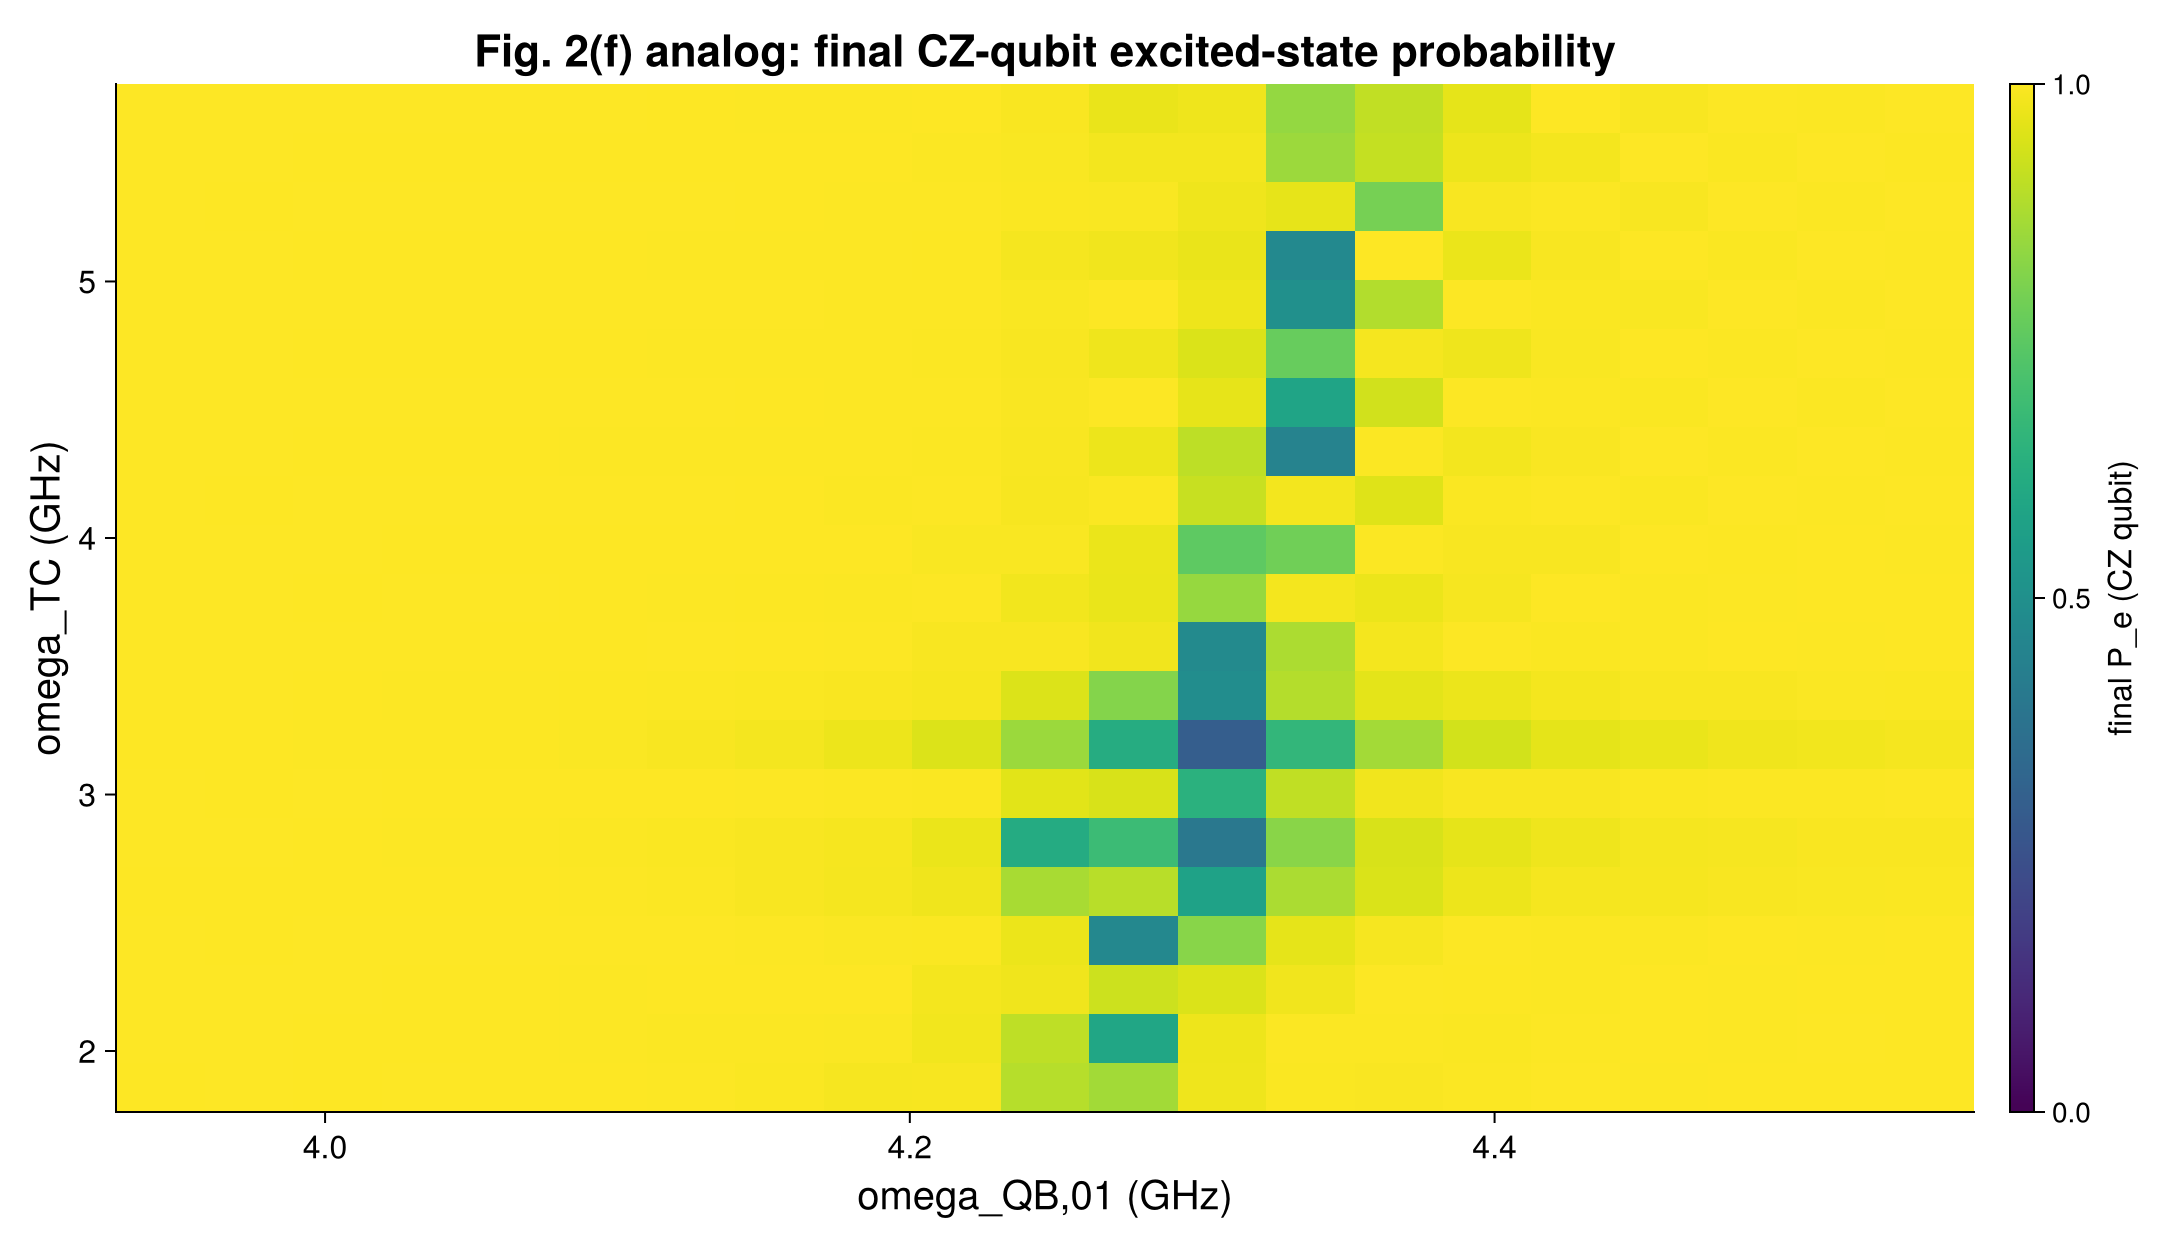

(saved = (svg = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2f_cz_population_map.svg", png = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2f_cz_population_map.png"), cz_t_gate = 120.0, best_cz_point = (q_flux = 0.198, tc_flux = 0.36, q_ghz = 4.1962, tc_ghz = 4.2256, value = 0.2947, q_edge = :interior, tc_edge = :interior), scan_rounds = 2, scan_flux_window = (q = (0.12, 0.24), tc = (0.27999999999999997, 0.48)), display_window = (xlims = (3.928492860130092, 4.563972760512655), ylims = (1.762285519479125, 5.769747234269154)))

In [8]:
cz_scan_axes = branch_flux_axes(:cz; q_points = 21, tc_points = 21)
cz_scan_q_fluxes = cz_scan_axes.q_fluxes
cz_scan_tc_fluxes = cz_scan_axes.tc_fluxes
cz_t_gate = gate_times.cz

cz_scan = adaptive_qubit_excited_scan(
    cz_system,
    snapshot,
    cz_scan_q_fluxes,
    cz_scan_tc_fluxes,
    (1, 0, 1),
    cz_t_gate;
    branch = :cz,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)

x_cz = cz_scan.x_values
y_cz = cz_scan.y_values
matrix_cz = cz_scan.matrix
x_cz_sorted, y_cz_sorted, matrix_cz_sorted = ordered_heatmap_axes(x_cz, y_cz, matrix_cz)
best_cz_point = cz_scan.best_point
cz_display = (
    xlims = (minimum(x_cz_sorted), maximum(x_cz_sorted)),
    ylims = (minimum(y_cz_sorted), maximum(y_cz_sorted)),
)

cz_heatmap_fig = heatmap_figure(
    x_cz_sorted,
    y_cz_sorted,
    matrix_cz_sorted;
    title = "Fig. 2(f) analog: final CZ-qubit excited-state probability",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "omega_TC (GHz)",
    colorlabel = "final P_e (CZ qubit)",
    colorrange = (0.0, 1.0),
    xlims = cz_display.xlims,
    ylims = cz_display.ylims,
)
cz_heatmap_saved = save_figure(cz_heatmap_fig, repo_root, "figure2f_cz_population_map")
figure_exports[:figure2f] = cz_heatmap_saved

display(cz_heatmap_fig)

(
    saved = cz_heatmap_saved,
    cz_t_gate = cz_t_gate,
    best_cz_point = compact_namedtuple(best_cz_point),
    scan_rounds = cz_scan.rounds,
    scan_flux_window = (q = (first(cz_scan.q_fluxes), last(cz_scan.q_fluxes)), tc = (first(cz_scan.tc_fluxes), last(cz_scan.tc_fluxes))),
    display_window = cz_display,
)


## Step 7 - Quench sanity check and computational-phase interpretation

The previous two scan panels were computed by rebuilding the static Hamiltonian at each operating point. To confirm the same feature appears in a pulse-like picture, we now start from parked MOVE and CZ base systems and apply a constant `FluxControl` quench to the best scan points.

We also evaluate the computational `QB-CR` conditional phase at the best CZ-side scan point. In this reduced model, the phase stays near zero, which is the correct interpretation: panels (d) and (f) identify the **resonance mechanism**, not a finished calibrated computational CZ gate.


In [9]:
move_quench_population = quench_qubit_excited_population(
    move_system,
    snapshot,
    best_move_point.q_flux,
    best_move_point.tc_flux,
    (1, 0, 0),
    move_t_gate;
    branch = :move,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)

cz_quench_population = quench_qubit_excited_population(
    cz_system,
    snapshot,
    best_cz_point.q_flux,
    best_cz_point.tc_flux,
    (1, 0, 1),
    cz_t_gate;
    branch = :cz,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)

cz_phase_proxy = computational_phase_summary(
    cz_system,
    snapshot,
    best_cz_point.q_flux,
    best_cz_point.tc_flux,
    cz_t_gate;
    branch = :cz,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)

(
    move_static_min = compact_namedtuple(best_move_point),
    move_quench_final_p_e = round4(move_quench_population),
    cz_static_min = compact_namedtuple(best_cz_point),
    cz_quench_final_p_e = round4(cz_quench_population),
    cz_computational_phase = compact_namedtuple(cz_phase_proxy),
)


(move_static_min = (q_flux = 0.228, tc_flux = 0.36, q_ghz = 4.2283, tc_ghz = 4.2256, value = 0.1433, q_edge = :interior, tc_edge = :interior), move_quench_final_p_e = 0.1433, cz_static_min = (q_flux = 0.198, tc_flux = 0.36, q_ghz = 4.1962, tc_ghz = 4.2256, value = 0.2947, q_edge = :interior, tc_edge = :interior), cz_quench_final_p_e = 0.2947, cz_computational_phase = (q_flux = 0.198, tc_flux = 0.36, q_ghz = 4.1962, tc_ghz = 4.2256, conditional_phase_pi = -0.0001, max_leakage = 0.0))

## Step 8 - Optional truncation cross-check

This notebook defaults to `charge_cutoff = 3` for interactivity. The cell below can rerun the best MOVE and CZ scan points at `charge_cutoff = 4` to check that the qualitative story survives a modest truncation increase.


In [10]:
if RUN_TRUNCATION_CHECKS
    move_cutoff4 = final_qubit_excited_population(
        move_system,
        snapshot,
        best_move_point.q_flux,
        best_move_point.tc_flux,
        (1, 0, 0),
        move_t_gate;
        branch = :move,
        charge_cutoff = 4,
    )
    cz_cutoff4 = final_qubit_excited_population(
        cz_system,
        snapshot,
        best_cz_point.q_flux,
        best_cz_point.tc_flux,
        (1, 0, 1),
        cz_t_gate;
        branch = :cz,
        charge_cutoff = 4,
    )

    (
        move_cutoff3 = round4(best_move_point.value),
        move_cutoff4 = round4(move_cutoff4),
        cz_cutoff3 = round4(best_cz_point.value),
        cz_cutoff4 = round4(cz_cutoff4),
    )
else
    "Set RUN_TRUNCATION_CHECKS = true to rerun the low-P_e scan points at charge_cutoff = 4."
end


"Set RUN_TRUNCATION_CHECKS = true to rerun the low-P_e scan points at charge_cutoff = 4."

## Takeaways

- The notebook reproduces the **qualitative avoided-crossing physics** behind Fig. 2(c) and Fig. 2(d) with branch-specific exact-circuit local models.
- The MOVE and CZ map panels are now built from the paper-backed branch split `QB1-TC1-CR` and `QB2-TC2-CR`, respectively.
- The fixed-window scan maps are local **final qubit excited-state** readout proxies, not target-state transfer maps and not fully calibrated logical gates.
- The best CZ-side resonance point found here still does **not** by itself produce a large computational conditional phase, which is expected. A real logical gate still needs calibrated pulse timing, phase handling, and the higher-level `MOVE -> CZ -> MOVE` composition.


In [11]:
final_summary = (
    move_branch = branch_spec(:move).label,
    cz_branch = branch_spec(:cz).label,
    move_gap = compact_namedtuple(move_gap),
    cz_gap = compact_namedtuple(cz_gap),
    best_move_point = compact_namedtuple(best_move_point),
    best_cz_point = compact_namedtuple(best_cz_point),
    move_quench_final_p_e = round4(move_quench_population),
    cz_quench_final_p_e = round4(cz_quench_population),
    cz_computational_phase = compact_namedtuple(cz_phase_proxy),
    exported_figures = figure_exports,
)

final_summary


(move_branch = "QB1-TC1-CR", cz_branch = "QB2-TC2-CR", move_gap = (q_flux = 0.2325, q_ghz = 4.196, tc_flux = 0.34, tc_ghz = 4.6326, pair_abs = (2, 3), gap_ghz = 0.0047, lower_a_overlap = 0.8539, lower_b_overlap = 0.1405, upper_a_overlap = 0.1432, upper_b_overlap = 0.8551, a_pair_support = 0.9971, b_pair_support = 0.9956, lower_branch_support = 0.9944, upper_branch_support = 0.9983, support_score = 2.1775, third_mode_abs_index = 4.0, third_mode_support = 0.0072, third_mode_comparable = 0.0), cz_gap = (q_flux = 0.195, q_ghz = 4.2135, tc_flux = 0.34, tc_ghz = 4.6326, pair_abs = (5, 6), gap_ghz = 0.0142, lower_a_overlap = 0.0456, lower_b_overlap = 0.0, upper_a_overlap = 0.9443, upper_b_overlap = 0.0004, a_pair_support = 0.9899, b_pair_support = 0.0004, lower_branch_support = 0.0457, upper_branch_support = 0.9447, support_score = 1.0369, third_mode_abs_index = 7.0, third_mode_support = 0.9834, third_mode_comparable = 1.0), best_move_point = (q_flux = 0.228, tc_flux = 0.36, q_ghz = 4.2283, t